## 2D Histogram + NSF
Summary statistic: 2D histogram of (cS1, log(cS2)) per simulation, normalized to sum=1, with log(n_events) appended. No DeepSet — flat vector fed directly into LAMPE NSF.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy as sps
import matplotlib.pyplot as plt

import yaml
import wandb

import torch
import torch.nn as nn
from torch.utils import data

import ili
from ili.dataloaders import TorchLoader
from ili.inference.runner_lampe import LampeRunner
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2026-04-08 17:11:05.188396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775682665.208408   31719 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775682665.214586   31719 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 17:11:05.235710: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load config

In [2]:
with open("histogram_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg['out_dir'] = cfg['out_dir'].format(
    **cfg,
    num_samples=cfg['data']['num_samples'],
    n_bins=cfg['histogram']['n_bins'],
    hidden_features=cfg['model']['hidden_features'],
    num_transforms=cfg['model']['num_transforms'],
)

In [3]:
tags = [
    f"histogram-{cfg['histogram']['n_bins']}x{cfg['histogram']['n_bins']}",
    f"nsf_h{cfg['model']['hidden_features']}_t{cfg['model']['num_transforms']}",
    f"{cfg['data']['num_samples']:.1e}sims",
]

wandb.init(
    project=cfg['wandb']['project'],
    entity=cfg['wandb']['entity'],
    config=cfg,
    tags=tags,
)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/puehlengt/.netrc.
wandb: Currently logged in as: puehleng-tan (plt109) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load simulations

In [4]:
fname = f"{cfg['data']['base_dir']}/{cfg['data']['fname']}"
aa = np.load(fname, allow_pickle=True).item()
param_bag = aa['param_bag']
events_bag = aa['events_bag']

In [5]:
apt_param_config = {
    "g1": {
        "prior_type": "norm",
        "prior_args": {"mean": 0.1367, "std": 0.001},
        "allowed_range": [0, 1.0],
        "init_mean": 0.1367, "init_std": 0.001,
        "unit": "PE/photon", "doc": "g1"
    },
    "g2": {
        "prior_type": "norm",
        "prior_args": {"mean": 16.85, "std": 0.46},
        "allowed_range": [0, 100.0],
        "init_mean": 16.85, "init_std": 0.46,
        "unit": "PE/electron", "doc": "g2"
    },
    "ambe_nr_rate": {
        "prior_type": "free",
        "prior_args": {},
        "allowed_range": [0, 10000000000.0],
        "init_mean": 5500, "init_std": 100,
        "unit": "1", "doc": "total number of events in the AmBe NR calibration"
    }
}

## Train/val/test split

In [6]:
np.random.seed(42)

n_test = 10
validation_fraction = 0.1
num_samples = cfg['data']['num_samples']

permuted_idx = np.random.permutation(num_samples)
idx_test = permuted_idx[:n_test]
idx_remaining = permuted_idx[n_test:]
n_train = int((1 - validation_fraction) * len(idx_remaining))
idx_train = idx_remaining[:n_train]
idx_val = idx_remaining[n_train:]

## Compute bin edges from config

In [7]:
N_BINS = cfg['histogram']['n_bins']

cs1_edges = np.linspace(*cfg['histogram']['cs1_range'], N_BINS + 1)
log_cs2_edges = np.linspace(*cfg['histogram']['log_cs2_range'], N_BINS + 1)

print(f"cS1 edges:      [{cs1_edges[0]:.2f}, {cs1_edges[-1]:.2f}]")
print(f"log(cS2) edges: [{log_cs2_edges[0]:.2f}, {log_cs2_edges[-1]:.2f}]")

cS1 edges:      [0.00, 150.00]
log(cS2) edges: [2.10, 4.10]


## Build histogram dataset

In [8]:
def make_histogram(events, cs1_edges, log_cs2_edges):
    """
    events: np.ndarray shape (2, n_events)
    Returns flat vector: normalized 2D histogram (N_BINS*N_BINS,) + n_events (1,)
    """
    cs1 = events[0]
    log_cs2 = np.log10(events[1])
    n_events = len(cs1)

    h, _, _ = np.histogram2d(cs1, log_cs2, bins=[cs1_edges, log_cs2_edges])
    h = h / h.sum()

    return np.concatenate([h.flatten(), [n_events]]).astype(np.float32)

In [9]:
x_data = []
theta_data = []

for idx in range(num_samples):
    events = events_bag[idx]
    hist_vec = make_histogram(events, cs1_edges, log_cs2_edges)
    theta = np.array([v for v in param_bag[idx].values()], dtype=np.float32)
    x_data.append(hist_vec)
    theta_data.append(theta)

x_data = torch.tensor(np.stack(x_data))          # (num_samples, N_BINS*N_BINS + 1)
theta_data = torch.tensor(np.stack(theta_data))   # (num_samples, 3)

print(f"x_data shape:     {x_data.shape}")
print(f"theta_data shape: {theta_data.shape}")

x_data shape:     torch.Size([50000, 626])
theta_data shape: torch.Size([50000, 3])


In [ ]:
## Add small noise to histogram bins, then z-norm all features using training set stats
#NOISE_EPS = 1e-6
NOISE_EPS = 0.

x_data_np = x_data.numpy().copy()

# Add noise to histogram bins only (first N_BINS*N_BINS cols)
rng = np.random.default_rng(42)
x_data_np[:, :-1] += rng.uniform(0, NOISE_EPS, size=x_data_np[:, :-1].shape)

# Compute mean and std from training set only
x_mean = x_data_np[idx_train].mean(axis=0)   # (626,)
x_std  = x_data_np[idx_train].std(axis=0)    # (626,)
x_std  = np.where(x_std == 0, 1.0, x_std)    # avoid divide-by-zero for always-zero bins

x_data = torch.tensor((x_data_np - x_mean) / x_std, dtype=torch.float32)

print(f"x_data after z-norm: mean~{x_data[idx_train].mean():.3f}, std~{x_data[idx_train].std():.3f}")

x_data after z-norm: mean~0.000, std~1.000


In [11]:
import os, pickle

os.makedirs(cfg['out_dir'], exist_ok=True)
with open(f"{cfg['out_dir']}/x_norm_stats.pkl", 'wb') as f:
    pickle.dump({'x_mean': x_mean, 'x_std': x_std}, f)
print(f"Saved x_norm_stats to {cfg['out_dir']}/x_norm_stats.pkl")

Saved x_norm_stats to 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/x_norm_stats.pkl


In [12]:
np.shape(events), np.log10(5336), hist_vec[-1]

((2, 5336), np.float64(3.7272158209084925), np.float32(5336.0))

In [13]:
aa = x_data.numpy()
cc = []
for _ii in range(100):
    bb = aa[_ii,:]
    cc.append(np.sum(bb==0)/625)
cc = np.array(cc)

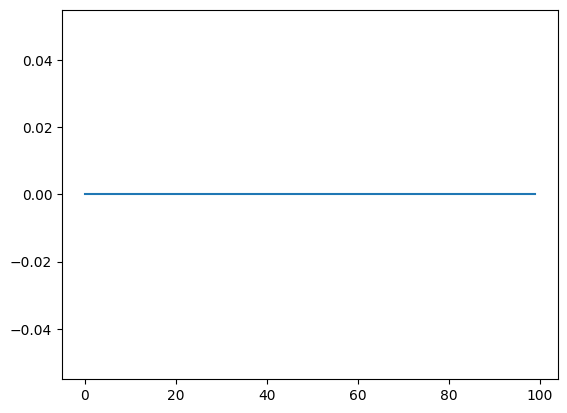

In [14]:
plt.plot(cc)

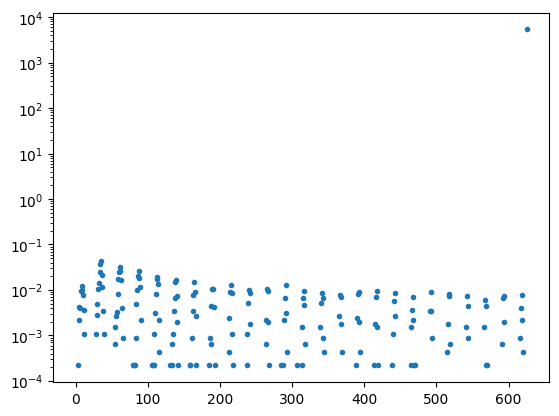

In [16]:
plt.plot(hist_vec, '.')
plt.yscale('log')

In [ ]:
np.shape(events), np.log10(5336), hist_vec[-1]

In [ ]:
aa = x_data.numpy()
cc = []
for _ii in range(100):
    bb = aa[_ii,:]
    cc.append(np.sum(bb==0)/625)
cc = np.array(cc)

In [ ]:
plt.plot(cc)

In [ ]:
plt.plot(hist_vec, '.')
plt.yscale('log')

## Visualize a few histograms

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    h = x_data[i, :-1].numpy().reshape(N_BINS, N_BINS)
    theta = theta_data[i].numpy()
    im = ax.imshow(h.T, origin='lower', aspect='auto',
                   extent=[cs1_edges[0], cs1_edges[-1], log_cs2_edges[0], log_cs2_edges[-1]])
    ax.set_xlabel('cS1 [PE]')
    ax.set_ylabel('log(cS2)')
    ax.set_title(f'g1={theta[0]:.4f}, g2={theta[1]:.2f}, rate={theta[2]:.0f}')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## DataLoaders

In [ ]:
class HistDataset(data.Dataset):
    def __init__(self, x, theta):
        self.x = x
        self.theta = theta

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.theta[idx]


hist_dataset = HistDataset(x_data, theta_data)

train_loader = data.DataLoader(
    hist_dataset, batch_size=cfg['training']['batch_size'],
    sampler=data.SubsetRandomSampler(idx_train), drop_last=True
)
val_loader = data.DataLoader(
    hist_dataset, batch_size=cfg['training']['batch_size'],
    sampler=data.SubsetRandomSampler(idx_val)
)

loader = TorchLoader(train_loader, val_loader)

## Prior

In [ ]:
means, stds, low_bounds, high_bounds = [], [], [], []
for param_info in apt_param_config.values():
    means.append(param_info['prior_args'].get('mean', param_info['init_mean']))
    stds.append(param_info['prior_args'].get('std',  param_info['init_std']))
    low_bounds.append(param_info['allowed_range'][0])
    high_bounds.append(param_info['allowed_range'][1])

prior = ili.utils.distributions_pt.IndependentTruncatedNormal(
    loc=means, scale=stds, low=low_bounds, high=high_bounds, device=device
)

## NSF (no embedding)

In [ ]:
nets = [
    ili.utils.load_nde_lampe(
        model=cfg['model']['type'],
        hidden_features=cfg['model']['hidden_features'],
        num_transforms=cfg['model']['num_transforms'],
        embedding_net=nn.Identity(),
        x_normalize=False,
        theta_normalize=True,
        device=device,
    )
]

## Train

In [ ]:
class WandbLampeRunner(LampeRunner):
    def _train_epoch(self, model, train_loader, val_loader, stepper):
        loss_train, loss_val = super()._train_epoch(model, train_loader, val_loader, stepper)
        wandb.log({'train_log_prob': -loss_train, 'val_log_prob': -loss_val})
        return loss_train, loss_val

In [ ]:
runner = WandbLampeRunner(
    prior=prior,
    nets=nets,
    device=device,
    train_args={
        'training_batch_size': cfg['training']['batch_size'],
        'learning_rate': cfg['training']['learning_rate'],
        'stop_after_epochs': cfg['training']['stop_after_epochs'],
        'clip_max_norm': cfg['training']['clip_max_norm'],
        'max_epochs': cfg['training']['max_epochs'],
    },
    proposal=None,
    out_dir=cfg['out_dir'],
)

In [ ]:
posterior_ensemble, summaries = runner(loader=loader)
wandb.finish()

In [ ]:
fig, ax = plt.subplots()
for m in summaries:
    ax.plot(m['training_log_probs'], ls='-', label='train')
    ax.plot(m['validation_log_probs'], ls='--', label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.grid()
ax.legend()

## Evaluate

In [ ]:
ind = 0
test_idx = idx_test[ind]
x_, theta_ = hist_dataset[test_idx]
y_ = theta_.numpy()

torch.manual_seed(1234)
samples = posterior_ensemble.sample((1000,), x_)
log_prob = posterior_ensemble.log_prob(samples, x_)
samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

In [ ]:
zzparams = theta_data.numpy()
param_names = list(apt_param_config.keys())

plt.figure(figsize=(15, 4))
for _ii, (key, val) in enumerate(apt_param_config.items()):
    zzz = zzparams[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)
    zzmean = val['prior_args'].get('mean', val['init_mean'])
    zzstd  = val['prior_args'].get('std',  val['init_std'])

    plt.subplot(131 + _ii)
    plt.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    plt.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label='Sampled from posterior')
    plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    plt.axvline(y_[_ii], color='red', linestyle='--', label='True value')
    plt.title(f'[{zzmin:.2f}, {zzmax:.2f}], {len(np.unique(zzz))} unique values')
    plt.xlabel(f'{key} [{val["unit"]}]')
    if _ii == 2:
        plt.legend(loc='center left', bbox_to_anchor=(1., 0.5))

In [ ]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names,
)
fig = metric(posterior=posterior_ensemble, x_obs=x_, theta_fid=y_)

In [ ]:
# PosteriorCoverage expects dataset items to be plain tensors (calls .to(device)),
# so wrap x-only data separately from the training dataset.
class HistDatasetX(data.Dataset):
    def __init__(self, x):
        self.x = x
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=cfg['out_dir'], labels=param_names,
    plot_list=["coverage", "histogram", "predictions", "tarp"],
    save_samples=True,
)
fig = metric(
    posterior=posterior_ensemble,
    x=HistDatasetX(x_data), theta=zzparams,
)

2026-04-07